# Import libraries

In [5]:
import os
import pandas as pd
import utils_emotions as ue
import utils_llm_filtering as ulf

In [6]:
INPUT_PATH = "../data/v2/clean_posts_bsky.csv"
RESULTS_PATH = "../data/v2/"

# Emotion detection

In [ ]:
df = pd.read_csv(INPUT_PATH)

emotion_classifier = ue.load_emotion_classifier(
    model_name="j-hartmann/emotion-english-distilroberta-base",
    device=-1  # use 0 if you have GPU
)

emotions_df = ue.add_emotion_columns(
    df,
    classifier=emotion_classifier,
    text_column="Clean_Comment",
    min_confidence=0.0,
    batch_size=32,
    progress_every=1000
)

display(ue.summarize_emotions(emotions_df))

os.makedirs(RESULTS_PATH, exist_ok=True)
emotions_df.to_csv(
    os.path.join(RESULTS_PATH, "bsky_with_emotions.csv"),
    index=False
)

Loading emotion classifier: j-hartmann/emotion-english-distilroberta-base


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 17942.63it/s]


Emotion classifier loaded.
Detected emotions for 1,024 posts...
Detected emotions for 2,016 posts...
Detected emotions for 3,008 posts...
Detected emotions for 4,000 posts...
Detected emotions for 5,024 posts...
Detected emotions for 6,016 posts...
Detected emotions for 7,008 posts...
Detected emotions for 8,000 posts...
Detected emotions for 9,024 posts...
Detected emotions for 10,016 posts...
Detected emotions for 11,008 posts...
Finished detecting emotions for 11,760 posts.


,emotion,rows
0,neutral,4177
1,joy,1826
2,fear,1739
3,surprise,1736
4,anger,1238
5,sadness,784
6,disgust,260


In [31]:
# Filter posts with less than 0.5 confidence in the emotion prediction
filtered_df = emotions_df[emotions_df['emotion_raw_score'] >= 0.5]

# Calculate the average confidence of the filtered posts
average_confidence = filtered_df['emotion_raw_score'].mean()
print(f"Average confidence of emotion predictions: {average_confidence:.2f}")

# amount of non-neutral posts
non_neutral_posts = filtered_df[filtered_df['emotion_label'] != 'neutral']
average_confidence = non_neutral_posts['emotion_raw_score'].mean()
neutral_posts = filtered_df[filtered_df['emotion_label'] == 'neutral']
print(f"Average confidence of non-neutral posts: {average_confidence:.2f}")
print(f"Average confidence of neutral posts: {neutral_posts['emotion_raw_score'].mean():.2f}")

# summarize
print(f"\nNumber of non-neutral posts: {len(non_neutral_posts)}")
display(ue.summarize_emotions(filtered_df))

# save filtered posts to a new CSV file
filtered_df.to_csv(
    os.path.join(RESULTS_PATH, "bsky_emotion_filtered_posts.csv"),
    index=False
)

Average confidence of emotion predictions: 0.76
Average confidence of non-neutral posts: 0.77
Average confidence of neutral posts: 0.74

Number of non-neutral posts: 5856


,emotion,rows
0,neutral,3392
1,fear,1443
2,joy,1422
3,surprise,1279
4,anger,951
5,sadness,583
6,disgust,178


/tmp/ipykernel_5448/1754107660.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_counts = filtered_df.groupby(filtered_df['Date'].dt.to_period('M')).size()


<Axes: title={'center': 'Number of Posts per Month'}, xlabel='Date'>

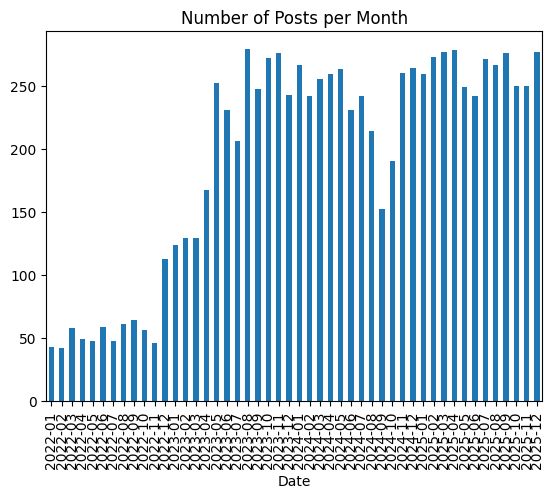

In [29]:
# check amount of data per month
    # convert 'Date' column to datetime
filtered_df['Date'] = pd.to_datetime(filtered_df['Date'], format='mixed')

    # group by month and count the number of posts
monthly_counts = filtered_df.groupby(filtered_df['Date'].dt.to_period('M')).size()

    # plot
monthly_counts.plot(kind='bar', title='Number of Posts per Month')

Emotion distribution:
emotion_label
neutral     0.366782
fear        0.156034
joy         0.153763
surprise    0.138300
anger       0.102833
sadness     0.063041
disgust     0.019247
Name: proportion, dtype: float64


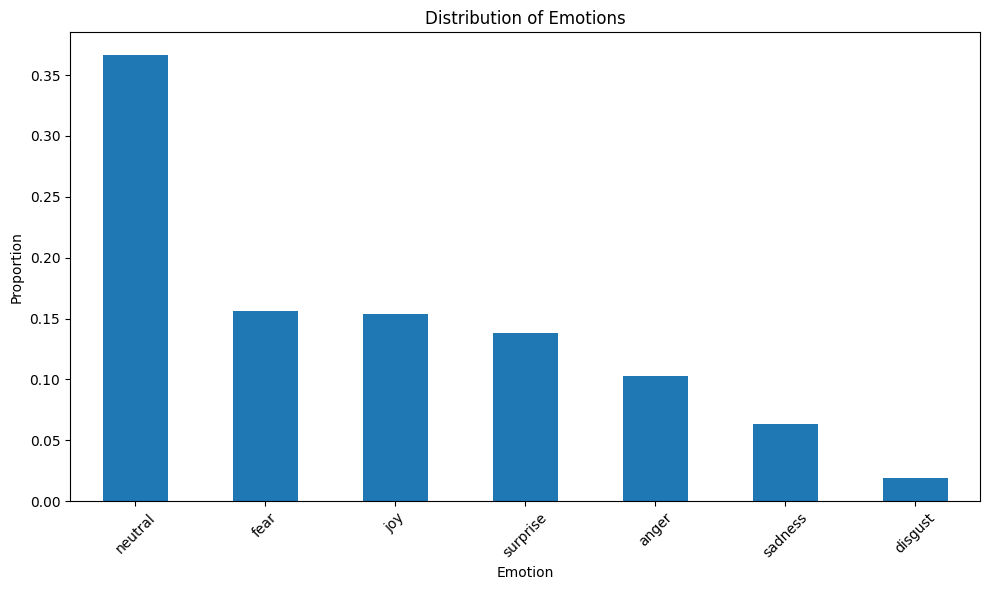

In [32]:
# Plot emotions distribution
emotion_distribution = filtered_df['emotion_label'].value_counts(normalize=True)
print("Emotion distribution:")
print(emotion_distribution)

# Plot the distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
emotion_distribution.plot(kind='bar')
plt.title('Distribution of Emotions')
plt.xlabel('Emotion')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Bart filtering

In [ ]:
# executed on cluster
# filtered_df = pd.read_csv(os.path.join(RESULTS_PATH, "bsky_emotion_filtered_posts.csv"))
# classifier = ulf.load_zero_shot_classifier(
#     model_name="facebook/bart-large-mnli",
#     device=-1  # use 0 if you have GPU
# )

# classified_df = ulf.add_llm_filter_columns(
#     filtered_df,
#     classifier=classifier,
#     text_column="Clean_Comment",
#     progress_every=100
# )

In [8]:
classified_df = pd.read_csv(os.path.join(RESULTS_PATH, "llm_classified_posts_bsky.csv"))
ai_df, review_df = ulf.filter_ai_related_comments(
    classified_df,
    min_score=0.50,
    min_margin=0.05,
    keep_uncertain_ai=True
)

os.makedirs(RESULTS_PATH, exist_ok=True)
ai_df.to_csv(os.path.join(RESULTS_PATH, "llm_filtered_ai_posts_bsky.csv"), index=False)
review_df.to_csv(os.path.join(RESULTS_PATH, "llm_review_posts_bsky.csv"), index=False)

Kept 3,140 AI-related comments.
Flagged 9,228 comments for rejection or manual review.


In [9]:
# how many posts in ai_df and review_df
print(f"Number of AI-related posts: {len(ai_df)}")
print(f"Number of posts for review: {len(review_df)}")

Number of AI-related posts: 3140
Number of posts for review: 9228


In [11]:
# After prompt reviewing of the review_df
after_review_df = pd.read_csv(os.path.join(RESULTS_PATH, "llm_review_related_ai_misclassified.csv"))
print(f"Number of posts after review: {len(after_review_df)}")

Number of posts after review: 7609


In [14]:
# Concat ai_df and after_review_df
final_ai_df = pd.concat([ai_df, after_review_df], ignore_index=True, sort=False)

# Some borderline AI rows are present in both files because filter_ai_related_comments
# keeps uncertain AI rows while also appending them to review_df for auditing.
if "Post_ID" in final_ai_df.columns:
    duplicate_posts = final_ai_df["Post_ID"].duplicated().sum()
    final_ai_df = final_ai_df.drop_duplicates(subset=["Post_ID"], keep="last").reset_index(drop=True)
    print(f"Dropped {duplicate_posts:,} duplicate Post_ID rows after joining.")

print(f"Final AI-related posts: {len(final_ai_df):,}")
print(f"Final columns: {len(final_ai_df.columns)}")

Dropped 3,120 duplicate Post_ID rows after joining.
Final AI-related posts: 7,629
Final columns: 30


In [13]:
# Save the joined AI-related DataFrame to a new CSV file
final_ai_df.to_csv(
    os.path.join(RESULTS_PATH, "bsky_AI_filtered_posts.csv"),
    index=False
)